In [1]:
MODEL_CLS = "cin"
EMBEDDING_DIM = 16
PATH_WORK_DIR = "../.."

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.chdir(PATH_WORK_DIR)
print(f"DIRECTORY: {os.getcwd()}")

DIRECTORY: c:\Users\jayar\Desktop\바탕 화면\REPO\PROJECT\M1-PJT_DL


In [4]:
import sys
sys.path.append("src")

# Packages

In [ ]:
import pandas as pd
from ctr import config, featuremap, datamodule, trainer, evaluator, utils
import fm

In [ ]:
PATH = f"./config/{MODEL_CLS}.yaml"
cfg = config.build_config(PATH)

In [7]:
utils.seed.main(cfg.seed)

ALL SEEDS RESET: 42


# Load Data

In [8]:
PATH = "./data/criteo.csv"
df = pd.read_csv(PATH)

In [9]:
y_col = "label"
X_col = df.columns.difference([y_col])

In [10]:
NUMERIC_COL = [
    col 
    for col in X_col 
    if "I" in col
]

CATEGORICAL_COL = [
    col 
    for col in X_col 
    if "C" in col
]

In [11]:
y = df[y_col]
X = df[X_col]

# Data Preparation

In [ ]:
kwargs = dict(
    X=X,
    y=y,
    cfg=cfg.datamodule,
    scaling=NUMERIC_COL,
)

dataloaders = datamodule.build_datamodule(**kwargs)

In [ ]:
kwargs = dict(
    X=X,
    cat_cols=CATEGORICAL_COL,
    num_cols=NUMERIC_COL,
)

feature_map = featuremap.build_feature_map(**kwargs)

# Modeling

In [14]:
kwargs = dict(
    **cfg.model.params,
    embedding_dim=EMBEDDING_DIM,
    feature_map=feature_map,
)

model = fm.cin.CompressedInteractionNetworks(**kwargs)

# Training

In [ ]:
kwargs = dict(
    model=model,
    cfg=cfg.trainer,
)

opt = trainer.build_trainer(**kwargs)

In [16]:
kwargs = dict(
    trn_loader=dataloaders["trn"],
    val_loader=dataloaders["val"],
)

records = opt.fit(**kwargs)

BEST EPOCH: 1
BEST SCORE: 0.7685


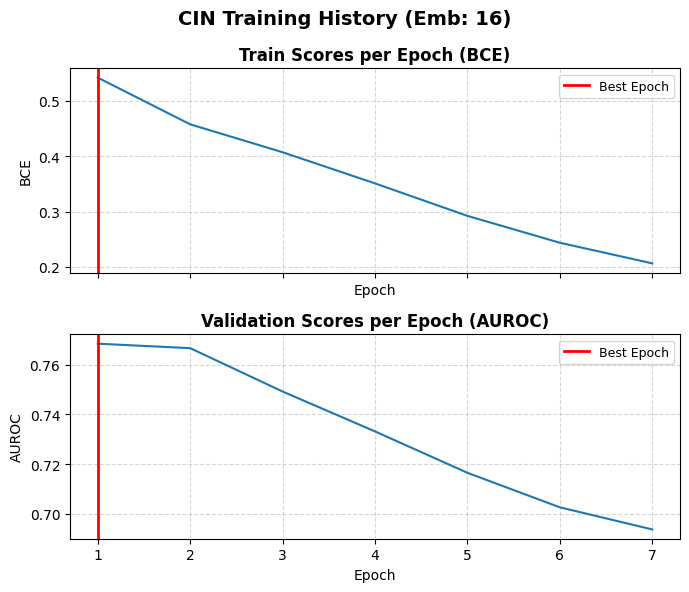

In [17]:
SUPTITLE = f"CIN Training History (Emb: {EMBEDDING_DIM})"
TRN_SCORE = "BCE"
VAL_SCORE = "AUROC"
FIGSIZE = (7,3)

kwargs = dict(
    records=records,
    suptitle=SUPTITLE,
    trn=TRN_SCORE,
    val=VAL_SCORE,
    figsize=FIGSIZE,
)

utils.visualizer.main(**kwargs)

# Evaluation

In [ ]:
kwargs = dict(
    model=model, 
    threshold=records["threshold"],
)

msr = evaluator.build_evaluator(**kwargs)

TST: 100%|██████████| 196/196 [00:03<00:00, 52.45it/s]


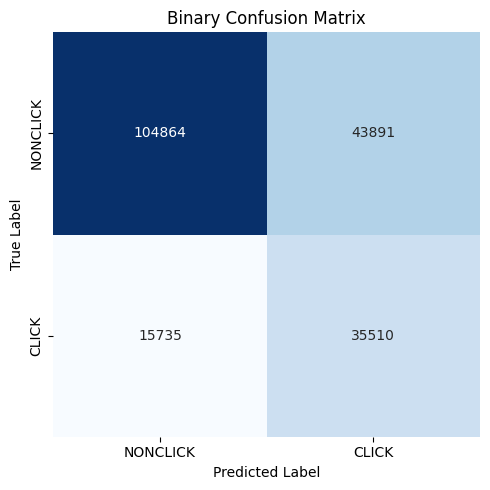

In [19]:
result, metrics_sheet = msr(dataloaders["tst"])

In [20]:
metrics_sheet

,threshold,accuracy,precision,recall,f1,auroc,logloss
0,0.259258,0.70187,0.447224,0.692946,0.543606,0.769367,0.476606


# Save

In [21]:
PATH = f'./result/score/{MODEL_CLS}_{EMBEDDING_DIM}.csv'

kwargs = dict(
    path_or_buf=PATH,
    index=False,
)

result.to_csv(**kwargs)

In [22]:
PATH = f'./result/metric/{MODEL_CLS}_{EMBEDDING_DIM}.csv'

kwargs = dict(
    path_or_buf=PATH,
    index=False,
)

metrics_sheet.to_csv(**kwargs)

In [23]:
PATH = f'./checkpoints/{MODEL_CLS}_{EMBEDDING_DIM}.pth'

kwargs = dict(
    obj=model,
    path=PATH,
)

utils.checkpointer.save(**kwargs)